# 03 — Evaluate the Intent Classifier on the Held-Out Test Set

This notebook loads the exported model weights from `models/classifier/`
and evaluates them against `data/processed/test.csv` — data the model
has never seen during training or hyperparameter decisions.

**This is the final gate.** Do not export or ship the model until this
notebook passes both thresholds:

- Overall accuracy > 90%
- Per-class F1 > 0.85 on every class

If anything fails, go back to notebook 01 to add examples for the
failing class, then retrain in notebook 02, then re-run this notebook.

**Input:**  `models/classifier/` and `data/processed/test.csv`  
**Output:** PASS or FAIL verdict with full per-class breakdown


## 1. Imports and configuration


In [6]:
import pandas as pd
from pathlib import Path
from setfit import SetFitModel
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROC_DIR  = Path('../data/processed')
MODEL_DIR = Path('../models/classifier')

INTENT_CLASSES  = ['news', 'factual', 'code', 'research', 'commercial', 'general']
ACCURACY_THRESHOLD = 0.90
F1_THRESHOLD = 0.85

print('Evaluation notebook ready.')
print(f'Model directory : {MODEL_DIR}')
print(f'Test data : {PROC_DIR / "test.csv"}')
print(f'Accuracy threshold : {ACCURACY_THRESHOLD}')
print(f'F1 threshold : {F1_THRESHOLD}')


Evaluation notebook ready.
Model directory : ../models/classifier
Test data : ../data/processed/test.csv
Accuracy threshold : 0.9
F1 threshold : 0.85


## 2. Load the saved model

Loading from disk confirms the saved artifact works correctly,
not just the in-memory model from notebook 02.


In [7]:
import os

model_path = os.path.abspath(str(MODEL_DIR))
print(f'Loading from : {model_path}')
print(f'Path exists : {os.path.exists(model_path)}')
print(f'Contents : {os.listdir(model_path)}')

model = SetFitModel.from_pretrained(model_path, local_files_only=True)

print('Model loaded from disk.')
print(f'Labels : {model.labels}')

Loading from : /home/festus/ml/opensearch-models/models/classifier
Path exists : True
Contents : ['config_setfit.json', 'sentence_bert_config.json', 'tokenizer.json', '1_Pooling', 'special_tokens_map.json', 'config.json', 'model.safetensors', 'config_sentence_transformers.json', 'model_head.pkl', 'vocab.txt', 'tokenizer_config.json', 'README.md', 'modules.json']
Model loaded from disk.
Labels : ['news', 'factual', 'code', 'research', 'commercial', 'general']


## 3. Load the test set

This split was written by notebook 01 and has never been used
during training or any hyperparameter decision.


In [8]:
test_df = pd.read_csv(PROC_DIR / 'test.csv')

print(f'Test examples : {len(test_df)}')
print()
print('Test class distribution:')
print(test_df['intent'].value_counts().reindex(INTENT_CLASSES).to_string())


Test examples : 127

Test class distribution:
intent
news          20
factual       20
code          24
research      22
commercial    20
general       21


## 4. Run inference on the test set


In [9]:
import time

test_texts = test_df['query'].tolist()
test_labels = test_df['intent'].tolist()

t0 = time.time()
predictions = list(model.predict(test_texts))
elapsed = time.time() - t0

print(f'Inference complete in {elapsed:.2f}s for {len(test_texts)} examples')
print(f'Throughput : {len(test_texts)/elapsed:.1f} examples/sec')
print()
print(f'first 5 predictions : {predictions[:5]}')
print(f'first 5 labels : {test_labels[:5]}')


Inference complete in 6.60s for 127 examples
Throughput : 19.2 examples/sec

first 5 predictions : [np.str_('research'), np.str_('factual'), np.str_('code'), np.str_('general'), np.str_('commercial')]
first 5 labels : ['research', 'factual', 'code', 'general', 'commercial']


## 5. Overall accuracy


In [10]:
overall_accuracy = accuracy_score(test_labels, predictions)
accuracy_pass = overall_accuracy >= ACCURACY_THRESHOLD

status = 'PASS' if accuracy_pass else 'FAIL'
print(f'{status}  Overall accuracy : {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)')
print(f'     Threshold       : {ACCURACY_THRESHOLD*100:.0f}%')


PASS  Overall accuracy : 0.9843 (98.43%)
     Threshold       : 90%


## 6. Per-class precision, recall, F1


In [11]:
report = classification_report(
    test_labels,
    predictions,
    labels=INTENT_CLASSES,
    output_dict=True,
)

report_df = pd.DataFrame(report).T.loc[
    INTENT_CLASSES,
    ['precision', 'recall', 'f1-score', 'support']
]
report_df = report_df.round(4)
print('Per-class metrics on test set:')
print(report_df.to_string())


Per-class metrics on test set:
            precision  recall  f1-score  support
news           1.0000    1.00    1.0000     20.0
factual        1.0000    0.95    0.9744     20.0
code           0.9600    1.00    0.9796     24.0
research       1.0000    1.00    1.0000     22.0
commercial     1.0000    0.95    0.9744     20.0
general        0.9545    1.00    0.9767     21.0


## 7. F1 gate — per class


In [12]:
print('Per-class F1 gate:')
f1_gate_passed = True
for cls in INTENT_CLASSES:
    f1 = report[cls]['f1-score']
    status = 'PASS' if f1 >= F1_THRESHOLD else 'FAIL'
    bar = '#' * int(f1 * 20)
    print(f'{status}  {cls:<12}  F1={f1:.4f}  {bar}')
    if f1 < F1_THRESHOLD:
        f1_gate_passed = False

print()
gate_passed = accuracy_pass and f1_gate_passed
if gate_passed:
    print('All gates passed. Model is ready to copy to opensearch.')
else:
    print('One or more gates failed.')
    print('Add examples for the failing class in queries.csv,')
    print('rerun notebook 01, retrain in notebook 02, then rerun this notebook.')


Per-class F1 gate:
PASS  news          F1=1.0000  ####################
PASS  factual       F1=0.9744  ###################
PASS  code          F1=0.9796  ###################
PASS  research      F1=1.0000  ####################
PASS  commercial    F1=0.9744  ###################
PASS  general       F1=0.9767  ###################

All gates passed. Model is ready to copy to opensearch.


## 8. Confusion matrix


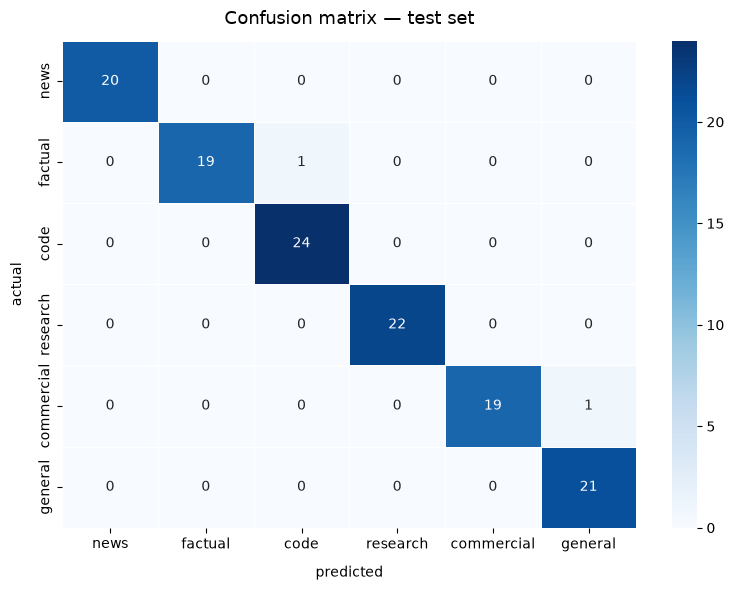

Diagonal = correct. Off-diagonal = misclassified.
Any row with significant off-diagonal values indicates a weak class.


In [13]:
cm = confusion_matrix(test_labels, predictions, labels=INTENT_CLASSES)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=INTENT_CLASSES,
    yticklabels=INTENT_CLASSES,
    linewidths=0.5,
    ax=ax,
)
ax.set_xlabel('predicted', labelpad=10)
ax.set_ylabel('actual', labelpad=10)
ax.set_title('Confusion matrix — test set', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print('Diagonal = correct. Off-diagonal = misclassified.')
print('Any row with significant off-diagonal values indicates a weak class.')


## 9. Inspect misclassified examples


In [14]:
test_df_copy = test_df.copy()
test_df_copy['predicted'] = predictions
misclassified = test_df_copy[test_df_copy['intent'] != test_df_copy['predicted']]

print(f'Misclassified: {len(misclassified)} of {len(test_df)} ({len(misclassified)/len(test_df)*100:.1f}%)')
print()

if len(misclassified) > 0:
    for _, row in misclassified.iterrows():
        print(f' query : {row["query"]}')
        print(f' actual : {row["intent"]}')
        print(f' predicted : {row["predicted"]}')
        print()
else:
    print('No misclassified examples.')


Misclassified: 2 of 127 (1.6%)

 query : noise cancelling headphones
 actual : commercial
 predicted : general

 query : bytes in a megabyte
 actual : factual
 predicted : code



## 10. Final verdict


In [15]:
print('=' * 60)
print('EVALUATION SUMMARY — TEST SET')
print('=' * 60)
print(f'Model : {MODEL_DIR}')
print(f'Test examples : {len(test_df)}')
print(f'Overall accuracy : {overall_accuracy*100:.2f}% (threshold: {ACCURACY_THRESHOLD*100:.0f}%)')
print()
print('Per-class F1:')
for cls in INTENT_CLASSES:
    f1 = report[cls]['f1-score']
    status = 'PASS' if f1 >= F1_THRESHOLD else 'FAIL'
    print(f'  {status}  {cls:<12}  {f1:.4f}')
print()
if gate_passed:
    print('VERDICT: PASS')
    print()
    print('Next step: copy models/classifier/ to opensearch/models/classifier/')
    print('See docs/EXPORT.md for the full transfer procedure.')
else:
    print('VERDICT: FAIL')
    print()
    print('Do not export. Fix the dataset and retrain before proceeding.')
print('=' * 60)


EVALUATION SUMMARY — TEST SET
Model : ../models/classifier
Test examples : 127
Overall accuracy : 98.43% (threshold: 90%)

Per-class F1:
  PASS  news          1.0000
  PASS  factual       0.9744
  PASS  code          0.9796
  PASS  research      1.0000
  PASS  commercial    0.9744
  PASS  general       0.9767

VERDICT: PASS

Next step: copy models/classifier/ to opensearch/models/classifier/
See docs/EXPORT.md for the full transfer procedure.
